In [1]:
import deepxde as dde
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# pde setup
from pde_geom import *
from net import *

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# should match openfoam mesh
x_min, x_max = 0.0, domain_length
y_min, y_max = 0.0, domain_width
nx, ny = 60, 40

x_centers = np.linspace(x_min + (x_max - x_min)/(2*nx), x_max - (x_max - x_min)/(2*nx), nx)
y_centers = np.linspace(y_min + (y_max - y_min)/(2*ny), y_max - (y_max - y_min)/(2*ny), ny)

X_grid, Y_grid = np.meshgrid(x_centers, y_centers)
coordinates_precice = np.vstack([X_grid.flatten(), Y_grid.flatten()]).T

In [3]:
def magnitude(vector_field):
    reshaped = vector_field.reshape((ny, nx, 2))
    x = reshaped[:, :, 0]
    y = reshaped[:, :, 1]
    return np.sqrt(x**2 + y**2)

# Define model

In [4]:
unsupervised_loss_terms

In [5]:
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

20

In [6]:
data_npz = np.load('training_data.npz')
X_train = data_npz['X_train'].astype(np.float32)
Y_train = data_npz['Y_train'].astype(np.float32)

SUPERVISED_BATCH_SIZE = 2**17

supervised_loss = dde.icbc.PointSetBC(X_train,Y_train, batch_size=SUPERVISED_BATCH_SIZE, shuffle=True)

loss_terms = unsupervised_loss_terms + [supervised_loss]

supervised_weight = 5
loss_weights = unsupervised_loss_weights + [supervised_weight]


data = dde.data.TimePDE(
    geom,
    navier_stokes_pde,
    loss_terms,
    num_domain=num_domain_points,
    num_boundary=num_boundary_points,
    num_initial=num_initial_points,
    num_test=num_test_points
)

model = dde.Model(data, net)
lr = 1e-4
model.compile(
    "adam", 
	decay=("inverse time", 10000, 0.5),
    lr=lr,
    loss_weights=loss_weights
)

Compiling model...
'compile' took 0.572480 s



In [7]:
def model_predict(x_mesh, y_mesh, time=0.0):
    n_points_mesh = len(x_mesh.flatten())
    t_values_mesh = np.full(n_points_mesh, time)
    
    # Input to model: (x, y, t)
    points_to_predict = np.vstack((x_mesh.flatten(), y_mesh.flatten(), t_values_mesh)).T
    
    # Model predicts (u, v, p)
    predictions = model.predict(points_to_predict)
    
    u_pred = predictions[:, 0].reshape(x_mesh.shape)
    v_pred = predictions[:, 1].reshape(x_mesh.shape)
    p_pred = predictions[:, 2].reshape(x_mesh.shape)

    Velocity = np.column_stack([u_pred.flatten(), v_pred.flatten()])
    Pressure = p_pred.flatten()
    
    return Velocity, Pressure

Velocity, Pressure = model_predict(X_grid, Y_grid, time=0.0)

In [9]:
# load model

model_path = os.path.join(training_output_dir, 'ns_obstacle_final-100000.pt')
model.restore(model_path)

In [8]:
model_checkpoint = dde.callbacks.ModelCheckpoint(
    training_output_dir + model_base_name,
    save_better_only=True,
    period=500
)

iterations = 100000
losshistory, train_state = model.train(
    iterations=iterations,
    display_every=100,
    callbacks=[model_checkpoint]
)

Training model...

Step      Train loss                                                                                                                                                          Test loss                                                                                                                                                           Test metric
0         [1.75e+00, 4.21e-01, 7.71e-01, 5.61e-02, 1.81e-02, 3.95e-02, 1.84e+01, 1.60e-02, 1.22e-01, 2.17e+00, 4.28e-03, 4.62e-02, 8.86e-03, 9.85e-02, 2.43e+00, 1.32e+00]    [1.75e+00, 4.21e-01, 7.71e-01, 5.61e-02, 1.81e-02, 3.95e-02, 1.84e+01, 1.60e-02, 1.22e-01, 2.17e+00, 4.28e-03, 4.62e-02, 8.86e-03, 9.85e-02, 2.43e+00, 1.32e+00]    []  
100       [4.73e-02, 5.84e-01, 7.33e-02, 1.47e-02, 1.44e-03, 9.65e-04, 4.77e-01, 3.66e-03, 6.83e-03, 3.80e-01, 3.59e-03, 9.43e-04, 5.63e-02, 1.26e-01, 1.91e-02, 1.24e+00]    [4.73e-02, 5.84e-01, 7.33e-02, 1.47e-02, 1.44e-03, 9.65e-04, 4.77e-01, 3.66e-03, 6.83e-03, 3.80e-01, 3.59e-03, 9.4

In [ ]:
model_path = os.path.join(training_output_dir, f"{model_base_name}_final")
os.mkdir(training_output_dir) if not os.path.exists(training_output_dir) else None
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: train_dir/ns_obstacle_final


Saving loss history to train_dir/loss.dat ...
Saving training data to train_dir/train.dat ...


Saving test data to train_dir/test.dat ...


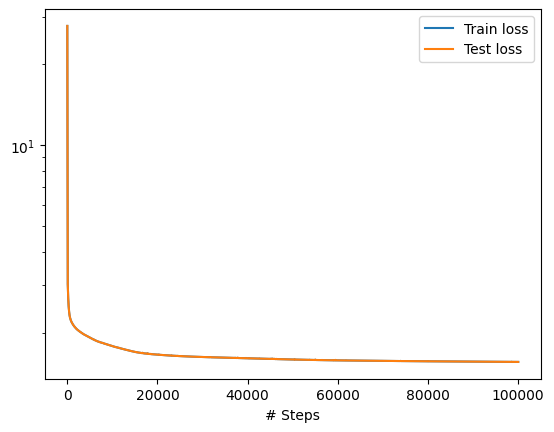

In [10]:
dde.saveplot(
    losshistory, 
    train_state, 
    issave=True, 
    isplot=True,
    output_dir=training_output_dir
)

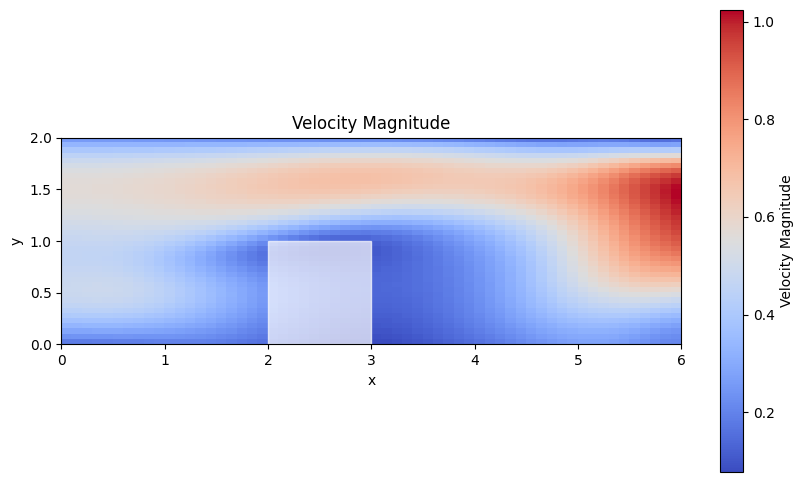

In [10]:
Velocity, Pressure = model_predict(X_grid, Y_grid, time=10.0)

velocity_magnitude = magnitude(Velocity)
plt.figure(figsize=(10, 6))

velocity_magnitude_reshaped = velocity_magnitude.reshape(ny, nx)
im = plt.imshow(velocity_magnitude_reshaped, cmap='coolwarm', origin='lower', 
               extent=(x_min, x_max, y_min, y_max))

plt.gca().add_patch(plt.Rectangle((obstacle_x0, obstacle_y0), 
                                 obstacle_x1-obstacle_x0, 
                                 obstacle_y1-obstacle_y0,
                                 color='white', alpha=0.7))

plt.colorbar(label='Velocity Magnitude')
plt.title('Velocity Magnitude')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(os.path.join(training_output_dir, 'velocity_magnitude.png'))
plt.show()

In [11]:
def update_plot(ax, field_data, time_value, field_name, vmin=None, vmax=None, cmap='coolwarm'):
    ax.clear()
    field_reshaped = field_data.reshape(ny, nx)
    
    im = ax.imshow(field_reshaped, cmap=cmap, origin='lower', 
                   extent=(x_min, x_max, y_min, y_max),
                   vmin=vmin, vmax=vmax)
    
    ax.add_patch(plt.Rectangle((obstacle_x0, obstacle_y0), 
                              obstacle_x1-obstacle_x0, 
                              obstacle_y1-obstacle_y0,
                              color='white', alpha=0.7))
    
    ax.set_title(f'{field_name} at t = {time_value:.2f}s')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    return [im]

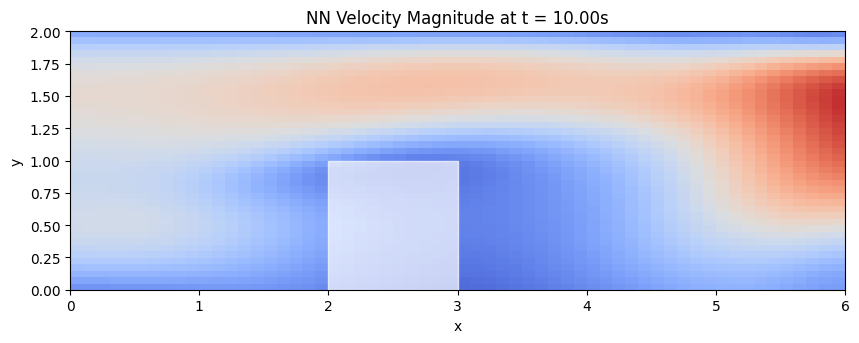

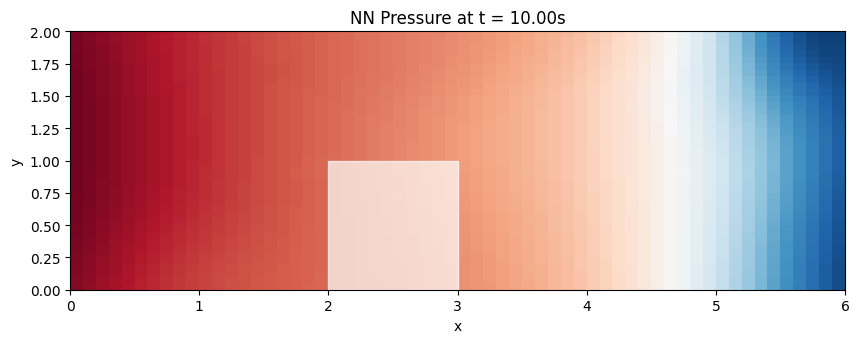

In [12]:
time_points = np.linspace(0, 10, 200)
nn_vel_mags = []
nn_pressures = []

for t in time_points:
    vel, press = model_predict(X_grid, Y_grid, time=t)
    nn_vel_mags.append(magnitude(vel).flatten())
    nn_pressures.append(press)

# NN velocity animation
fig_nn_vel, ax_nn_vel = plt.subplots(figsize=(10, 6))
nn_v_min, nn_v_max = np.min(nn_vel_mags), np.max(nn_vel_mags)

def animate_nn_velocity(frame):
    return update_plot(ax_nn_vel, nn_vel_mags[frame], time_points[frame],
                      'NN Velocity Magnitude', vmin=nn_v_min, vmax=nn_v_max)

ani_nn_vel = FuncAnimation(fig_nn_vel, animate_nn_velocity, frames=len(time_points), blit=True)
ani_nn_vel.save(os.path.join(training_output_dir, 'nn_velocity_animation.mp4'), writer='ffmpeg', fps=20)

# NN pressure animation
fig_nn_press, ax_nn_press = plt.subplots(figsize=(10, 6))
nn_p_min, nn_p_max = np.min(nn_pressures), np.max(nn_pressures)

def animate_nn_pressure(frame):
    return update_plot(ax_nn_press, nn_pressures[frame], time_points[frame],
                      'NN Pressure', vmin=nn_p_min, vmax=nn_p_max, cmap='RdBu_r')

ani_nn_press = FuncAnimation(fig_nn_press, animate_nn_pressure, frames=len(time_points), blit=True)
ani_nn_press.save(os.path.join(training_output_dir, 'nn_pressure_animation.mp4'), writer='ffmpeg', fps=20)

In [14]:
# n_pts = nx * ny
# if len(X_train) % n_pts != 0:
#     raise ValueError("Training points not multiple of nx*ny.")

# n_steps = len(X_train) // n_pts
# times = np.unique(X_train[:, 2])
# Y_reshaped = Y_train.reshape((n_steps, n_pts, 3))
# vel_mags = [magnitude(Y_reshaped[i, :, 0:2]).flatten() for i in range(n_steps)]
# pressures = [Y_reshaped[i, :, 2] for i in range(n_steps)]

# fps = 20
# frames = min(200, n_steps)  # 10 sec * 20 fps = 200 frames max
# stride = max(1, n_steps // frames)
# idx = np.arange(0, n_steps, stride)[:frames]

# def create_animation(data, filename, title, cmap='coolwarm'):
#     fig, ax = plt.subplots(figsize=(10, 6))
#     vmin, vmax = np.min(data), np.max(data)
    
#     def animate(frame):
#         ax.clear()
#         return update_plot(ax, data[idx[frame]], times[idx[frame]], title,
#                           vmin=vmin, vmax=vmax, cmap=cmap)
    
#     ani = FuncAnimation(fig, animate, frames=frames, blit=True)
#     ani.save(filename, writer='ffmpeg', fps=fps)
#     plt.show()
#     plt.close(fig)

# create_animation(vel_mags, 'velocity_animation.mp4', 'Magnitude')
# create_animation(pressures, 'pressure_animation.mp4', 'Pressure', 'RdBu_r')

In [1]:
!jupyter nbconvert --to script 'offline-training.ipynb'

[NbConvertApp] Converting notebook offline-training.ipynb to script
[NbConvertApp] Writing 7316 bytes to offline-training.py
